In [2]:
import numpy as np
from msi_visual.normalization import total_ion_count

def get_img(index):
    img = np.load(rf"E:\MSImaging-data\_msi_visual\Extractions\NRL4506-5um\Intelli-slide\20_bins\{index}.npy")
    img = total_ion_count(img)
    return img

img = get_img(0)
print(img.shape)

(1084, 1225, 21020)


In [3]:
vector = img.reshape(-1, img.shape[-1])
indices = np.argsort(vector, axis=-1)
print(indices.shape)


(1327900, 21020)


5766


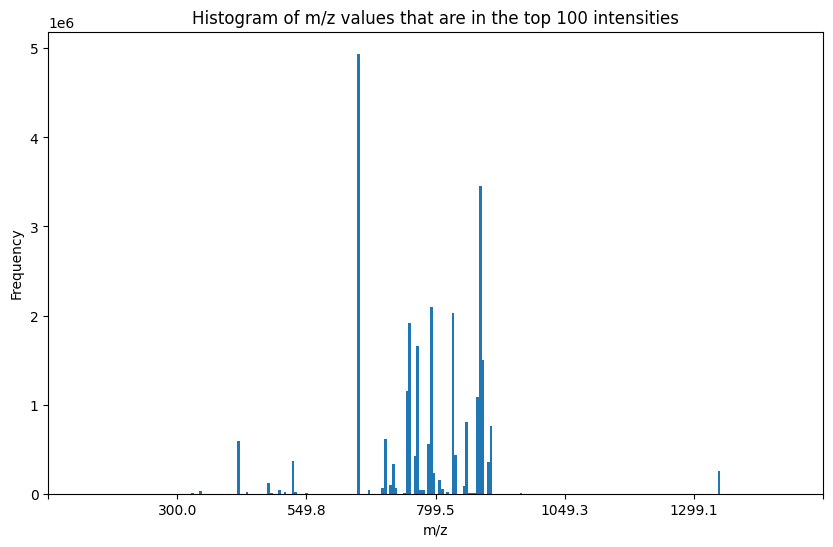

In [8]:
top_10 = indices[:, -20 : ][:]

print(len(set(top_10.flatten())))

import matplotlib.pyplot as plt

extraction_mzs = np.linspace(300, 1350, img.shape[-1])


plt.figure(figsize=(10,6))
plt.hist(top_10.flatten(), bins=200)
plt.title('Histogram of m/z values that are in the top 100 intensities')
plt.xlabel('Index')
plt.xlabel('m/z')
xticks = plt.xticks()[0]
plt.xticks(xticks, [f'{extraction_mzs[int(x)]:.1f}' if x >= 0 and x < len(extraction_mzs) else '' for x in xticks])

plt.ylabel('Frequency')
plt.show()
